In [4]:
# Execute aqui primeiro antes de qualquer outra coisa (PRIORIDADE)

import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Mostrar que o notebook está na raiz do projeto
sys.path.append('.')

from src.question1 import *
from src.question2 import *
from src.question3 import *

from tests import teste_q1
from tests import teste_q2
from tests import teste_q3

# Para exibir imagens dentro do notebook
%matplotlib inline

In [44]:
###################################################
#################### QUESTÃO 1 ####################
###################################################

In [ ]:
# 1.7 Questão que pede para testar a Redução e Ampliação usando uma foto de um rosto (meu)

img_cinza = cv2.imread('assets/foto.jpeg', cv2.IMREAD_GRAYSCALE)

# 1.3 - Redução
img_reduzida = retirar_metade_colunas_e_linhas(img_cinza)

# 1.6 - Ampliação
img_ampliada = aumentar_imagem(img_reduzida)

plt.figure(figsize=(20, 7))

# Para exibir a Original
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_cinza, cmap='gray')
plt.axis('off')

# Para exibir a Reduzida
plt.subplot(1, 3, 2)
plt.title("Reduzida (1.3)")
plt.imshow(img_reduzida, cmap='gray')
plt.axis('off')

# Para exibir a Apliada
plt.subplot(1, 3, 3)
plt.title("Ampliada (1.6)")
plt.imshow(img_ampliada, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 1.8 Questão: Teste de Redução e Ampliação em imagem COLORIDA

# 1. Lê a imagem original (em BGR)
img_bgr = cv2.imread('assets/foto.jpeg')

if img_bgr is not None:
    # 2. Separa os canais
    b, g, r = cv2.split(img_bgr)

    # 3. Processa cada canal individualmente (Redução 1.3)
    b_red = retirar_metade_colunas_e_linhas(b)
    g_red = retirar_metade_colunas_e_linhas(g)
    r_red = retirar_metade_colunas_e_linhas(r)
    img_reduzida_color = cv2.merge([b_red, g_red, r_red])

    # 4. Processa cada canal individualmente (Ampliação 1.6)
    b_amp = aumentar_imagem(b_red)
    g_amp = aumentar_imagem(g_red)
    r_amp = aumentar_imagem(r_red)
    img_ampliada_color = cv2.merge([b_amp, g_amp, r_amp])

    # --- EXIBIÇÃO ---
    plt.figure(figsize=(20, 7))

    # Para exibir, precisamos converter de BGR para RGB (Maldito Matplotlib)
    def to_rgb(img):
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Original Colorida
    plt.subplot(1, 3, 1)
    plt.title("Original Colorida")
    plt.imshow(to_rgb(img_bgr))
    plt.axis('off')

    # Reduzida Colorida
    plt.subplot(1, 3, 2)
    plt.title("Reduzida (Canais Separados)")
    plt.imshow(to_rgb(img_reduzida_color))
    plt.axis('off')

    # Ampliada Colorida
    plt.subplot(1, 3, 3)
    plt.title("Reconstruída (Canais Separados)")
    plt.imshow(to_rgb(img_ampliada_color))
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Erro ao carregar 'assets/foto.jpeg'. Verifique o arquivo!")

In [ ]:
# Rodar o código parar exibir resultados na pasta output
teste_q1.testar_monocromatica()
teste_q1.testar_colorida()

In [ ]:
###################################################
#################### QUESTÃO 2 ####################
###################################################

In [ ]:
# Resultados pedidos na 2.1 a 2.3 (2 PARTE A)

img_original = cv2.imread('assets/Image1.pgm')

if img_original is not None:
    # Processamento
    # Laplaciano Direto (pode vir com bastante ruído)
    agucada_direto, bordas_direto = agucar_laplaciano(img_original, sigma=None)
    
    # Com Suavização Gaussiana (Sigma 0.5 e 1.0)
    agucada_g05, _ = agucar_laplaciano(img_original, sigma=0.5)
    agucada_g10, _ = agucar_laplaciano(img_original, sigma=1.0)

    # Exibição para o Relatório
    plt.figure(figsize=(16, 12))

    # Original
    plt.subplot(2, 2, 1)
    plt.title("Original (Image1.pgm)")
    plt.imshow(img_original, cmap='gray')
    plt.axis('off')

    # Direto
    plt.subplot(2, 2, 2)
    plt.title("Laplaciano Direto\n(Sem Suavização)")
    plt.imshow(agucada_direto, cmap='gray')
    plt.axis('off')

    # Sigma 0.5
    plt.subplot(2, 2, 3)
    plt.title("Aguçada\n(Sigma = 0.5)")
    plt.imshow(agucada_g05, cmap='gray')
    plt.axis('off')

    # Sigma 1.0
    plt.subplot(2, 2, 4)
    plt.title("Aguçada\n(Sigma = 1.0)")
    plt.imshow(agucada_g10, cmap='gray')
    plt.axis('off')

    plt.tight_layout(pad=3)
    plt.show()

    # Bônus: Mostrar as bordas detectadas (o que o Laplaciano "vê")
    plt.figure(figsize=(16, 6))
    plt.title("Bordas Detectadas pelo Laplaciano (Detalhe)")
    plt.imshow(bordas_direto, cmap='gray')
    plt.axis('off')
    plt.show()
else:
    print("Erro: Não foi possível carregar 'assets/Image1.pgm'.")

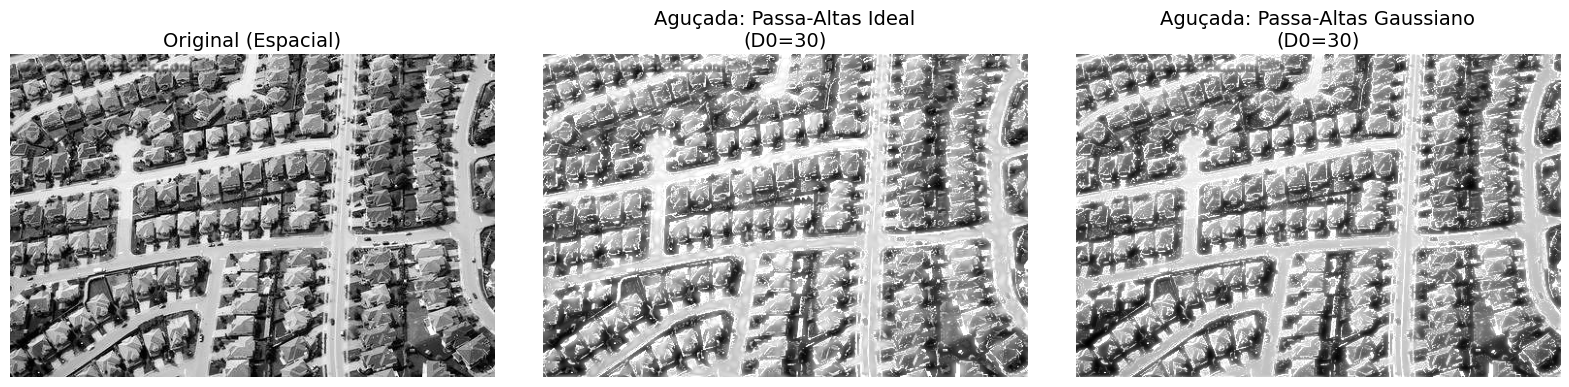

In [ ]:
# Parte B (Comparando o resultado final da imagem aguçada usando os dois tipos de filtros de frequência.)
img_original = cv2.imread('assets/Image1.pgm', cv2.IMREAD_GRAYSCALE)

if img_original is not None:
    # Processamento
    agucada_ideal, bordas_ideal = agucar_frequencia(img_original, tipo_filtro="ideal", D0=30)
    agucada_gauss, bordas_gauss = agucar_frequencia(img_original, tipo_filtro="gaussiano", D0=30)

    # Exibição com plt.subplot clássico
    plt.figure(figsize=(20, 7))
    
    # Esse comando aproxima as imagens tirando o espaço branco entre elas
    plt.subplots_adjust(wspace=0.1)

    # Imagem 1: Original
    plt.subplot(1, 3, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title("Original (Espacial)", fontsize=14)
    plt.axis('off')

    # Imagem 2: Filtro Ideal
    plt.subplot(1, 3, 2)
    plt.imshow(agucada_ideal, cmap='gray')
    plt.title("Aguçada: Passa-Altas Ideal\n(D0=30)", fontsize=14)
    plt.axis('off')

    # Imagem 3: Filtro Gaussiano
    plt.subplot(1, 3, 3)
    plt.imshow(agucada_gauss, cmap='gray')
    plt.title("Aguçada: Passa-Altas Gaussiano\n(D0=30)", fontsize=14)
    plt.axis('off')

    plt.show()
else:
    print("Erro ao carregar imagem.")

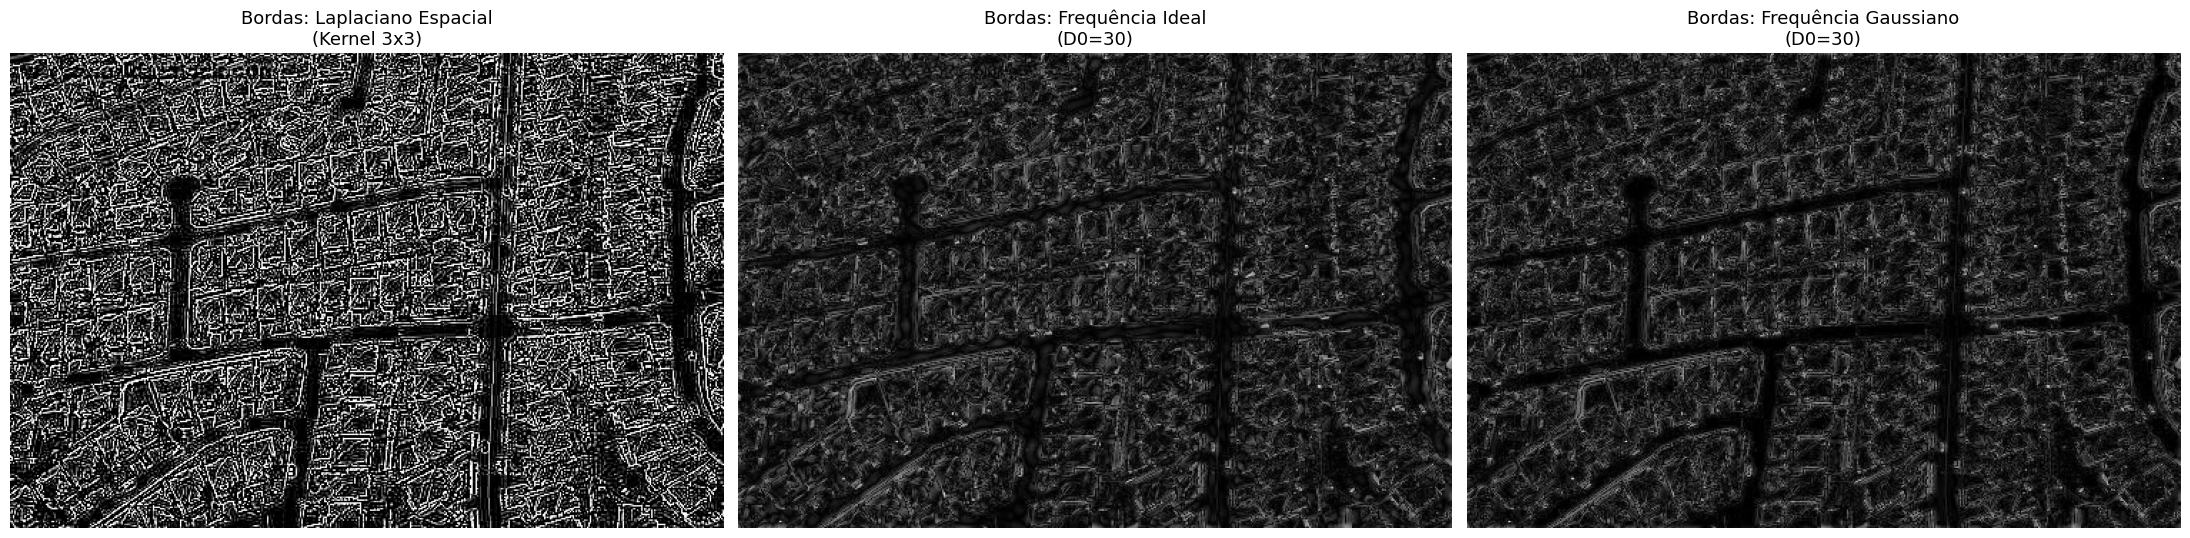

In [ ]:
# Comparação das bordas dos filtros

if img_original is not None:
    # Obtém bordas espaciais (Parte A)
    _, bordas_espacial = agucar_laplaciano(img_original, sigma=None)
    
    # Obtém bordas de frequência (Parte B) - Já processadas acima
    # agucada_ideal, bordas_ideal ...
    # agucada_gauss, bordas_gauss ...

    plt.figure(figsize=(22, 7))

    # Bordas Laplaciano Espacial
    plt.subplot(1, 3, 1)
    plt.title("Bordas: Laplaciano Espacial\n(Kernel 3x3)", fontsize=13)
    plt.imshow(bordas_espacial, cmap='gray')
    plt.axis('off')

    # Bordas Filtro Ideal
    plt.subplot(1, 3, 2)
    plt.title("Bordas: Frequência Ideal\n(D0=30)", fontsize=13)
    plt.imshow(bordas_ideal, cmap='gray')
    plt.axis('off')

    # Bordas Filtro Gaussiano
    plt.subplot(1, 3, 3)
    plt.title("Bordas: Frequência Gaussiano\n(D0=30)", fontsize=13)
    plt.imshow(bordas_gauss, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Rodar o código parar exibir resultados na pasta output
teste_q2.testar_questao2_parteA()
teste_q2.testar_questao2_parteB()

In [ ]:
###################################################
#################### QUESTÃO 3 ####################
###################################################

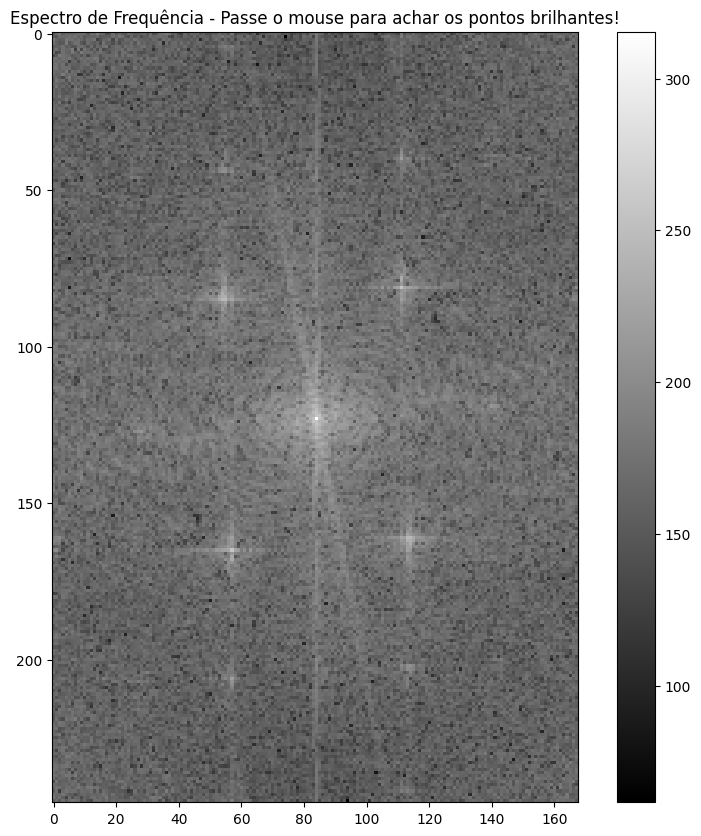

In [5]:
# Tentando atirar nos pontos brilhantes pra achar as coordenadas certas

import numpy as np
import matplotlib.pyplot as plt
import cv2

# Carrega a imagem original Moire
img_moire = cv2.imread('assets/moire.tif', 0)

# Calcula a FFT e faz o Shift para o centro
F = np.fft.fft2(img_moire)
Fshift = np.fft.fftshift(F)

# Calcula a Magnitude e aplica Log para visualizar melhor
magnitude = 20 * np.log(np.abs(Fshift))

# Exibe o espectro para você achar os pontos
plt.figure(figsize=(10, 10))
plt.imshow(magnitude, cmap='gray')
plt.title("Espectro de Frequência - Passe o mouse para achar os pontos brilhantes!")
plt.colorbar()
plt.show()

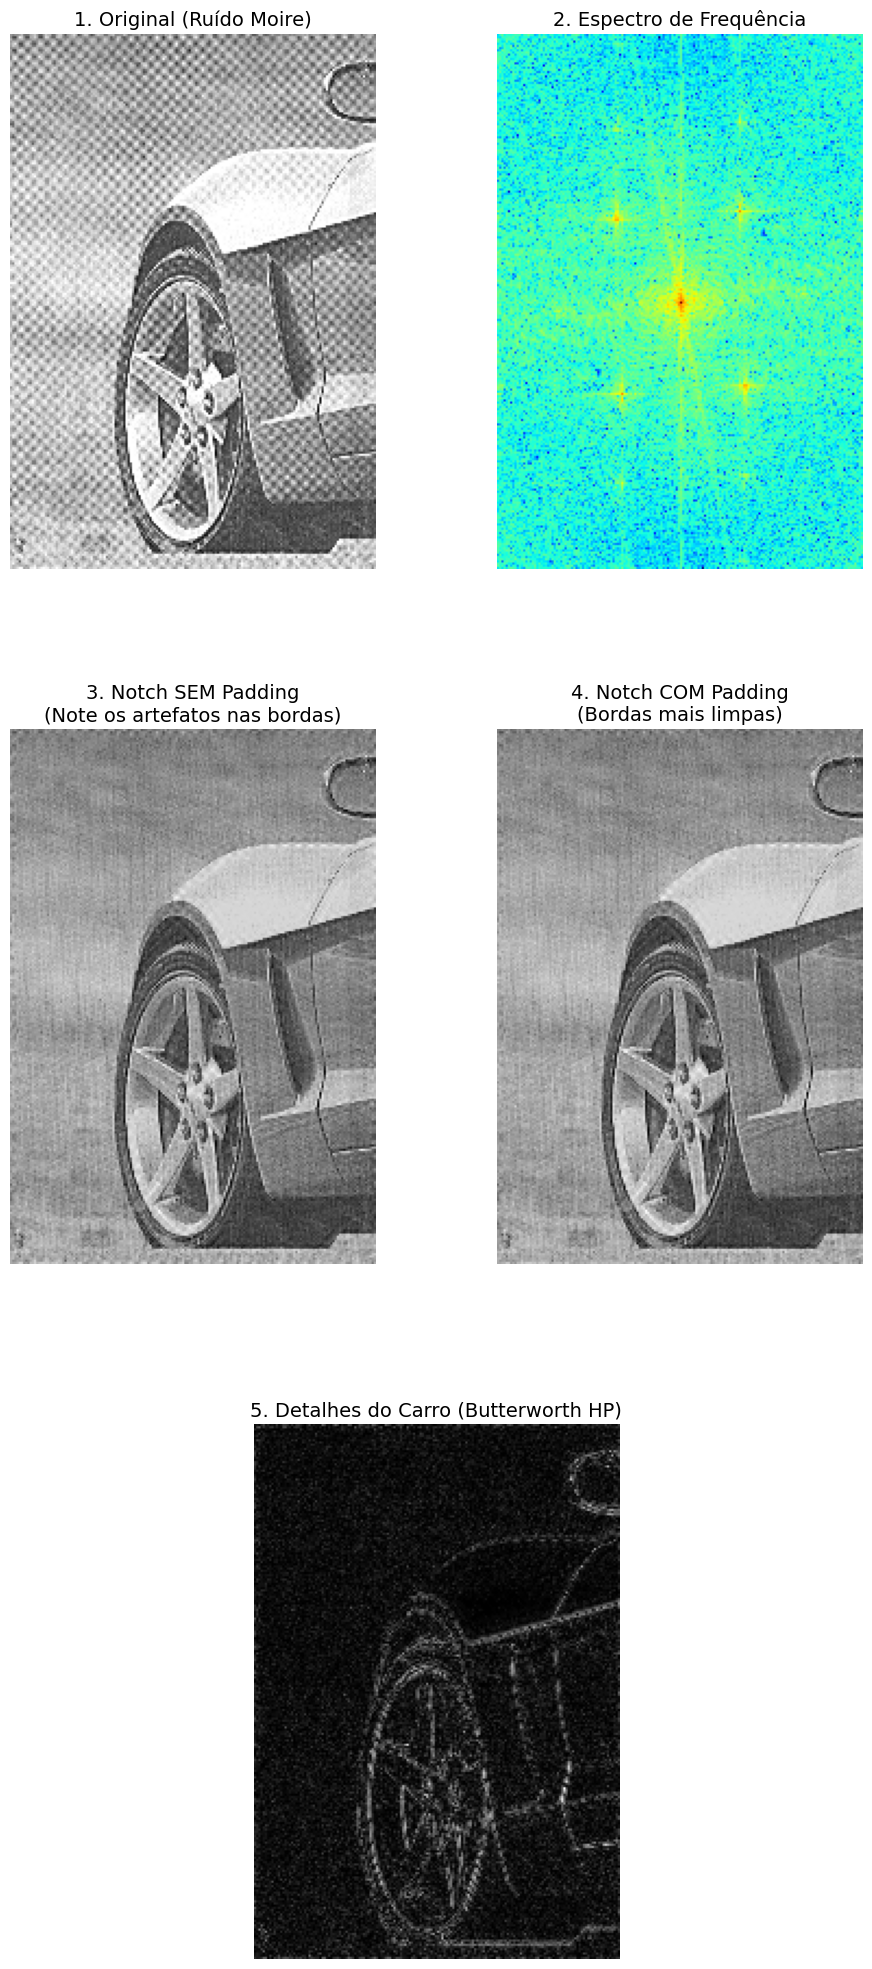

In [13]:
# Questão 3 - Notch Filter com e sem Padding
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_moire = cv2.imread('assets/moire.tif', cv2.IMREAD_GRAYSCALE)

if img_moire is not None:
    M, N = img_moire.shape

    # 4 pares de pontos (8 coordenadas) - Frequências principais e harmônicas
    pontos = [
        (38, 30), (-38, -30),
        (42, -32), (-42, 32),
        (76, 60), (-76, -60),
        (84, -64), (-84, 64)
    ]

    # --- 1. Notch SEM padding ---
    h_notch_sem = filtro_notch_rejeita(img_moire, pontos, D0=10, n=4)
    img_limpa_sem = aplicar_filtro_frequencia(img_moire, h_notch_sem)
    img_limpa_sem_norm = cv2.normalize(img_limpa_sem, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # --- 2. Butterworth Detalhes ---
    h_bw = filtro_butterwoth_passa_altas(img_limpa_sem, D0=30, n=4)
    detalhes = aplicar_filtro_frequencia(img_limpa_sem, h_bw)
    detalhes_norm = cv2.normalize(detalhes, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # --- 3. Notch COM padding ---
    img_padded = np.zeros((2 * M, 2 * N), dtype=np.float32)
    img_padded[0:M, 0:N] = img_moire
    pontos_padded = [(u * 2, v * 2) for u, v in pontos]

    h_notch_com = filtro_notch_rejeita(img_padded, pontos_padded, D0=20, n=4)
    img_limpa_com = aplicar_filtro_frequencia(img_padded, h_notch_com)
    img_limpa_com_cortada = img_limpa_com[0:M, 0:N] 
    img_limpa_com_norm = cv2.normalize(img_limpa_com_cortada, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # --- 4. Espectro de Frequência ---
    f_shift = np.fft.fftshift(np.fft.fft2(img_moire))
    espectro = np.log(1 + np.abs(f_shift))

    # ==========================================
    # --- EXIBIÇÃO NO NOTEBOOK 
    # ==========================================
    
    plt.figure(figsize=(12, 25))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    # Original
    plt.subplot(3, 2, 1)
    plt.title("1. Original (Ruído Moire)", fontsize=14)
    plt.imshow(img_moire, cmap='gray')
    plt.axis('off')

    # Espectro
    plt.subplot(3, 2, 2)
    plt.title("2. Espectro de Frequência", fontsize=14)
    plt.imshow(espectro, cmap='jet')
    plt.axis('off')

    # # Notch SEM Padding
    plt.subplot(3, 2, 3)
    plt.title("3. Notch SEM Padding\n(Note os artefatos nas bordas)", fontsize=14)
    plt.imshow(img_limpa_sem_norm, cmap='gray')
    plt.axis('off')

    # Notch COM Padding
    plt.subplot(3, 2, 4)
    plt.title("4. Notch COM Padding\n(Bordas mais limpas)", fontsize=14)
    plt.imshow(img_limpa_com_norm, cmap='gray')
    plt.axis('off')

    # Detalhes (Butterworth)
    plt.subplot(3, 1, 3)
    plt.title("5. Detalhes do Carro (Butterworth HP)", fontsize=14)
    plt.imshow(detalhes_norm, cmap='gray')
    plt.axis('off')

    plt.show()
else:
    print("Erro: Não encontrei o arquivo 'assets/moire.tif'.")